# GitHub Activity Visualisation 

In [2]:
from dotenv import load_dotenv  # Load environment variables
from main import run_pipeline  # Main pipeline execution
from github_client import repo  # GitHub repository client
from preprocess import preprocess_issue_data  # Data preprocessing
from data_fetch import get_file_contributors_df  # Fetch contributors data
from analysis import (
    find_missing_contributors_from_readme_and_github,
    calculate_pr_merge_rate,
    analyze_pr_review_time,
    analyze_issue_resolution
)  # Analysis functions

import plotly.io as pio  # Plotly rendering interface

load_dotenv()  # Load variables from .env file

# Set default Plotly renderer to 'iframe_connected' for Jupyter Notebook display
pio.renderers.default = 'iframe_connected'

# Run the main data processing pipeline and obtain results
results = run_pipeline()

# Extract individual dataframes from the results dictionary
commits_df = results["commits_df"]
pr_df = results["pr_df"]
contributors_df = results["contributors_df"]
stats_df = results["stats_df"]
contrib_summary_df = results["contrib_summary_df"]
issue_df = results["issue_df"]
readme_contribs_df = results["readme_contribs_df"]
glossary_contribs_df = results["glossary_contribs_df"]



Loading from cache: cache_contributors.json
Loading from cache: cache_commits.json
Loading from cache: cache_prs.json
Loading from cache: cache_issues.json
Loading from cache: cache_comments.json
Loading from cache: cache_glossary_contribs.json
Loading from cache: cache_readme_contributors.json


In [3]:
#Basic Information of GitHub Repository
print(f"Repository name: {repo.name}")
print(f"Description: {repo.description}")
print(f"Stars: {repo.stargazers_count}")
print(f"Forks: {repo.forks_count}")

merge_rate, merge_rate_msg = calculate_pr_merge_rate(pr_df)
print(merge_rate_msg) 

msg = analyze_pr_review_time(pr_df)
print(msg)

print(f"Numbers of Issue: {len(issue_df)}")
issue_msg = analyze_issue_resolution(issue_df)
print(issue_msg)

Repository name: glosario
Description: A multilingual glossary for computing and data science terms.
Stars: 121
Forks: 239
Total Pull Requests: 706, Merged: 626, Merge Rate: 88.67%
Average PR merge time (days): 28.42
Numbers of Issue: 114
Median issue resolution time: 36.0 days


In [4]:
from visualization import (
    plot_contributor_activity_interactive,
    plot_retention_curve,
    plot_commit_count_barchart,
    plot_pr_merge_pie_plotly,
    plot_contributor_activity_multi,
    plot_monthly_unique_committers,
    plot_pr_trend,
    plot_merge_time,
    plot_commit_frequency,
    plot_commit_heatmap,
    plot_issue_resolution_time_distribution,
    plot_pr_created_vs_merged,
    plot_top_contributors,
    plot_issue_labels,
    plot_lang_labels,
    plot_issue_monthly_trend,
    plot_contribution_type_barplot,
    plot_language_label_treemap,
    print_language_label_tree
)

## 1.Contributor Analysis

In [6]:
#Contributor ranking by GitHub activity contribution type — Bar chart
plot_contributor_activity_multi(contrib_summary_df)

In [7]:
# Contributor ranking by programming language and file type statistics — Bar chart
plot_contributor_activity_interactive(stats_df, top_n=10)


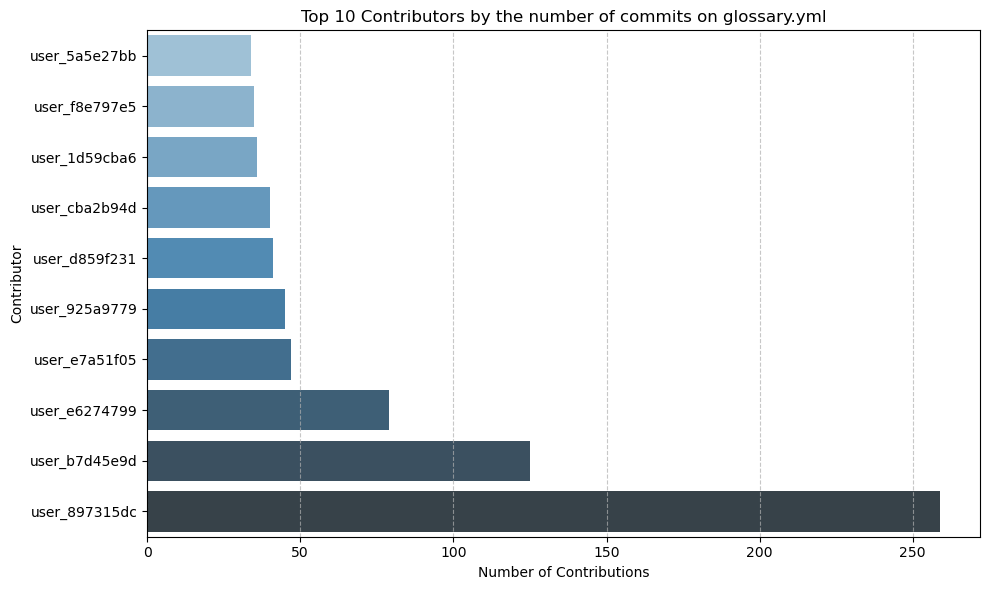

In [8]:
#Core glossary file contribution ranking — Bar chart
plot_top_contributors(glossary_contribs_df, top_n=10)

In [9]:
#README file contributor omission detection — Text
find_missing_contributors_from_readme_and_github()

Contributors on GitHub but missing in README (username): 4
mmcsamcm
beamilz-ensino
jnywong-test
brownsarahm


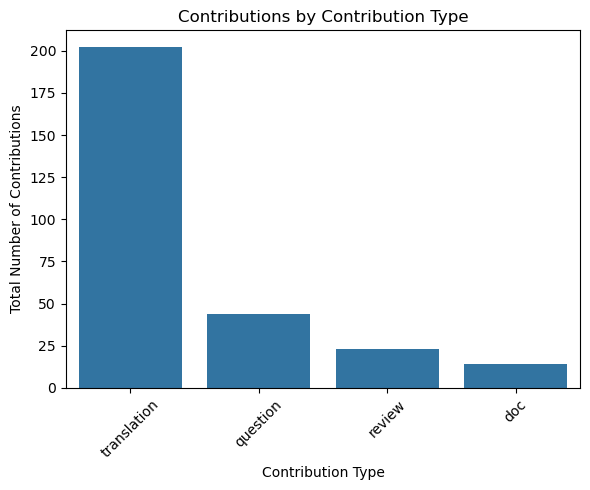

In [10]:
#Contributor type distribution based on README specifications — Bar chart
plot_contribution_type_barplot(readme_contribs_df)

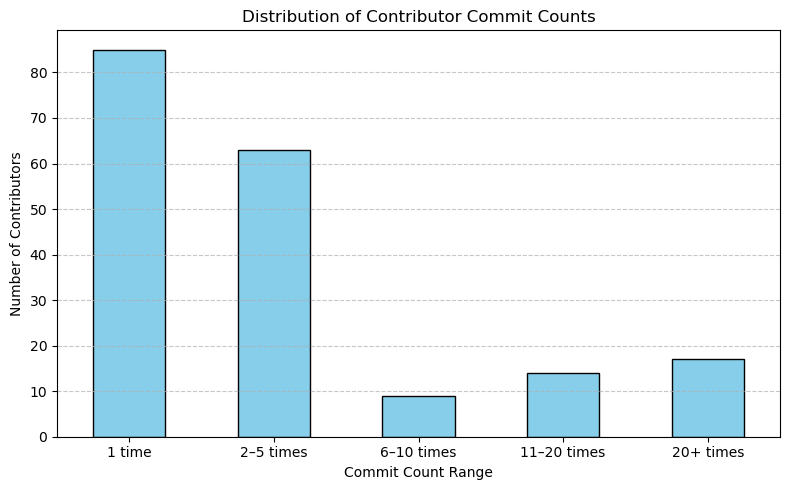

In [11]:
#Contributor commit frequency distribution — Bar chart
plot_commit_count_barchart(contributors_df)

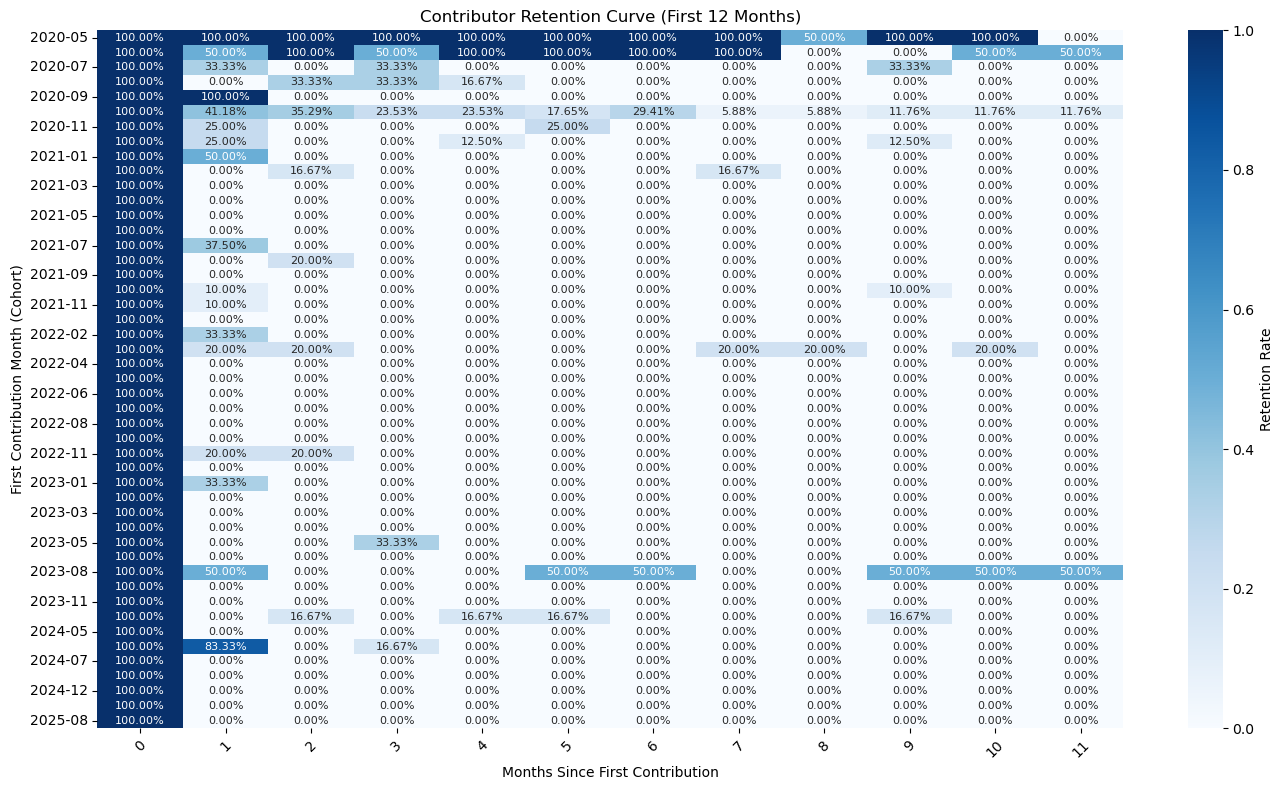

In [12]:
#Contributor retention analysis — Heat map
plot_retention_curve(commits_df)

## 2. Commit Activity Analysis

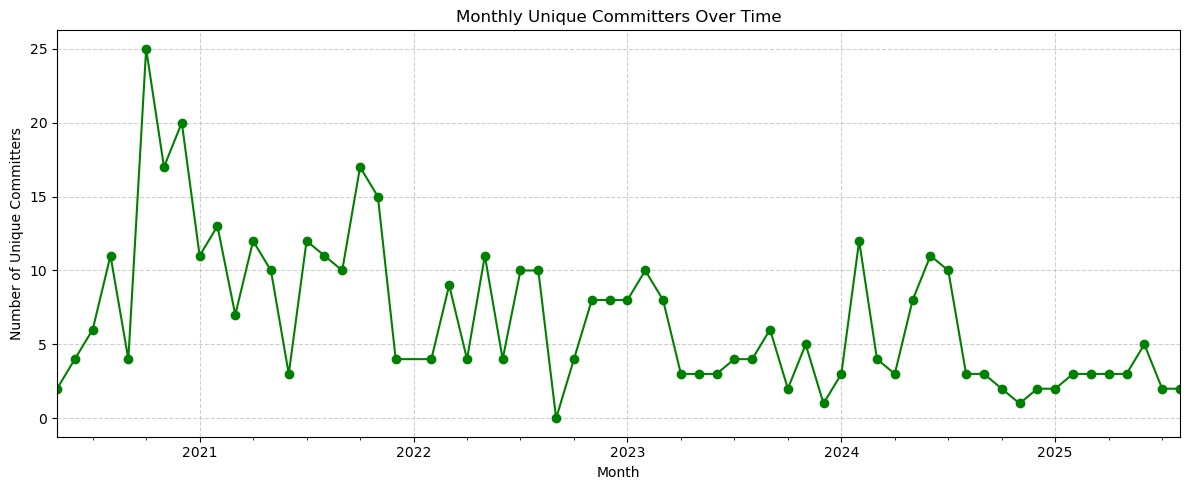

In [14]:
#Contributor number trend — line chart
plot_monthly_unique_committers(commits_df)

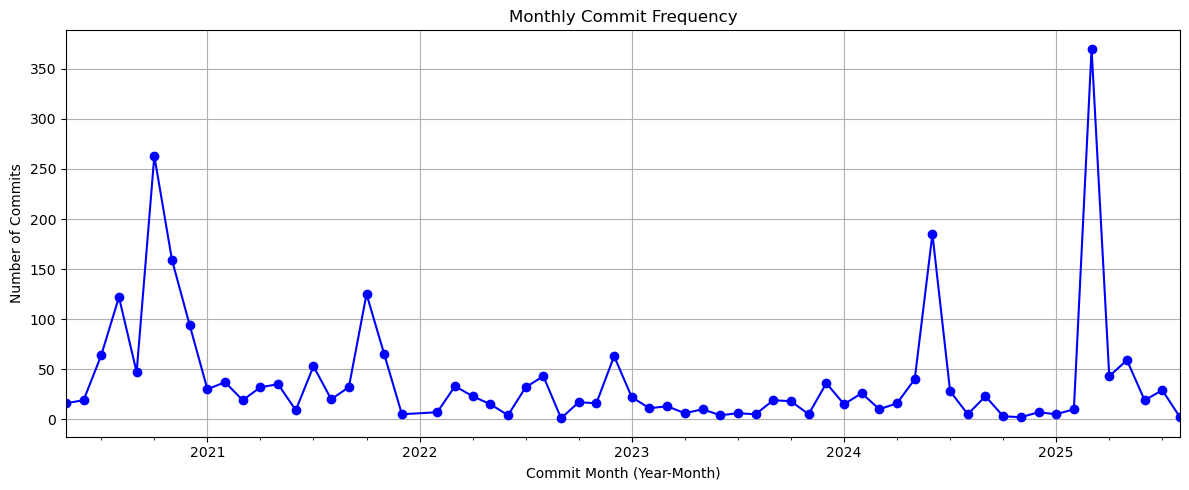

In [15]:
#Commit count trend — Line chart
plot_commit_frequency(commits_df)

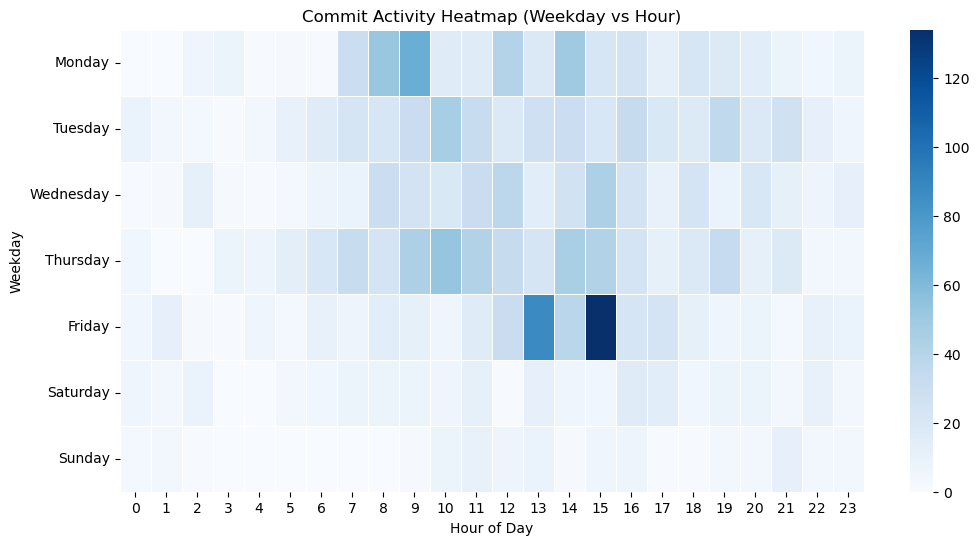

In [16]:
#Contributor commit time distribution — Heat map
plot_commit_heatmap(commits_df)

## 3.Pull Request Analysis 

In [18]:
#Pull Request status distribution — Pie chart
plot_pr_merge_pie_plotly(pr_df)

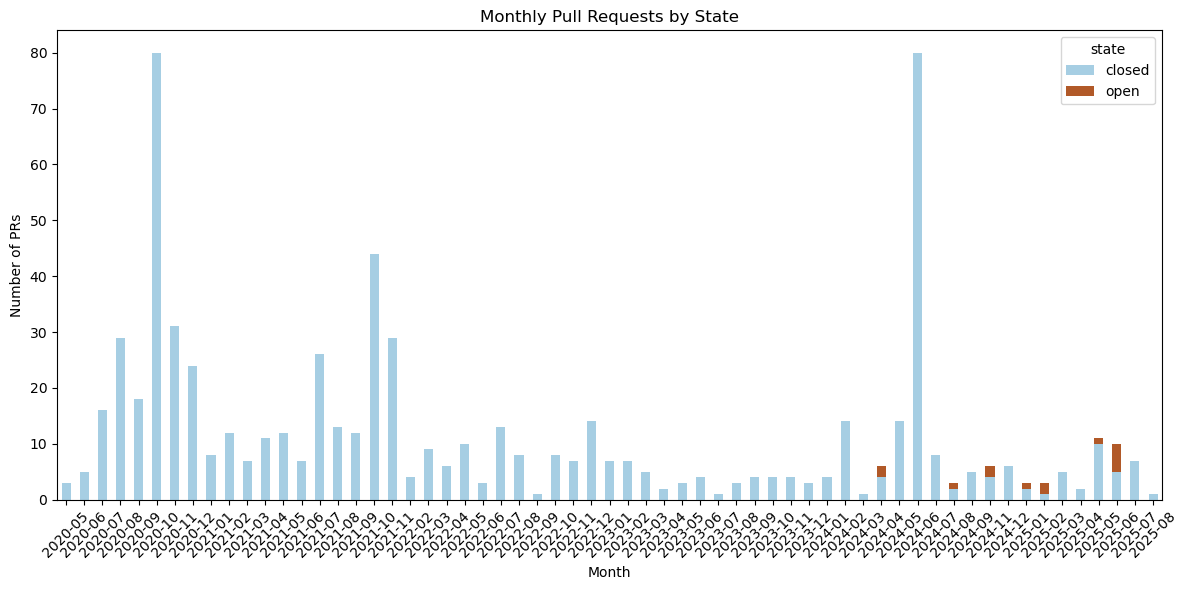

In [19]:
#Pull Request contribution count (based on Open/Closed and Merge status)——classified bar chart
plot_pr_trend(pr_df)

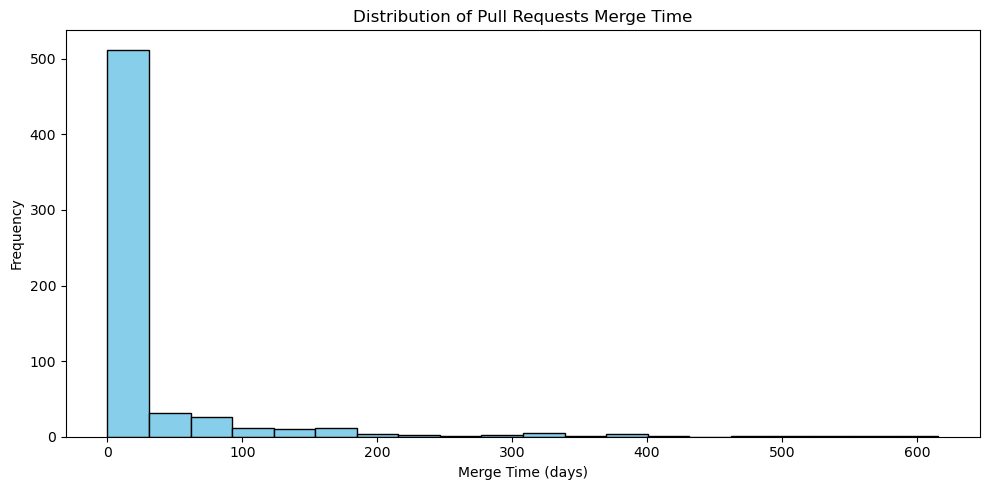

In [20]:
# Pull Request merge time distribution — Histogram
plot_merge_time(pr_df)

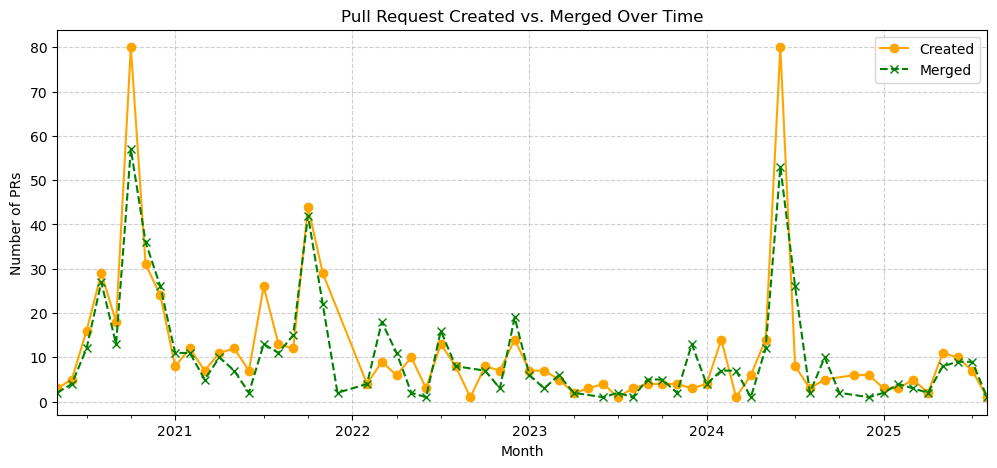

In [21]:
# Pull Request creation and merge count trends — Dual line chart
plot_pr_created_vs_merged(pr_df)

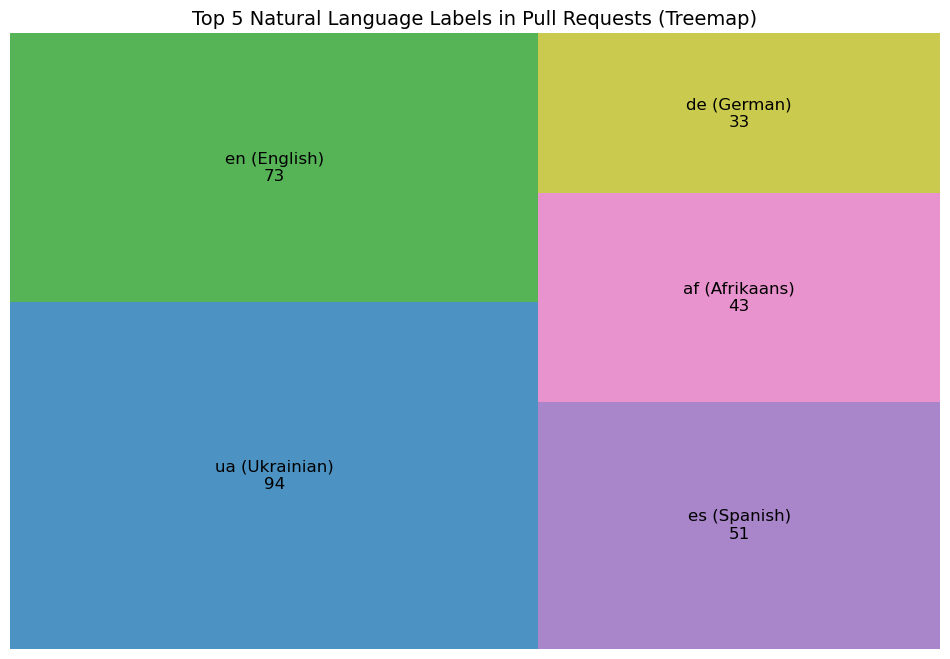

There are 388 pull requests involving languages (398 total language label occurrences)

lang
├── Ukrainian (ua): total 94, open 0, closed 94
├── English (en): total 73, open 2, closed 71
├── Spanish (es): total 51, open 3, closed 48
├── Afrikaans (af): total 43, open 0, closed 43
├── German (de): total 33, open 1, closed 32
├── French (fr): total 22, open 2, closed 20
├── Swahili (sw): total 18, open 0, closed 18
├── Portuguese (pt): total 16, open 0, closed 16
├── Arabic (ar): total 15, open 1, closed 14
├── Japanese (ja): total 8, open 1, closed 7
├── Tswana (tn): total 4, open 0, closed 4
├── Zulu (zu): total 3, open 1, closed 2
├── Italian (it): total 3, open 0, closed 3
├── Latin (la): total 3, open 0, closed 3
├── Dutch (nl): total 3, open 0, closed 3
├── Amharic (am): total 2, open 2, closed 0
├── Greek (el): total 2, open 0, closed 2
├── Panjabi (pa): total 1, open 1, closed 0
├── Hungarian (hu): total 1, open 0, closed 1
├── Chinese (zh): total 1, open 0, closed 1
├── Indonesi

In [22]:
#Pull Request language tag distribution — Tree diagram
plot_language_label_treemap(pr_df, label_col='language_labels', top_n=5, font_size=12)
#Pull Request language tag distribution — Text-based tree diagram
print_language_label_tree(pr_df)

## 4. Issue Analysis

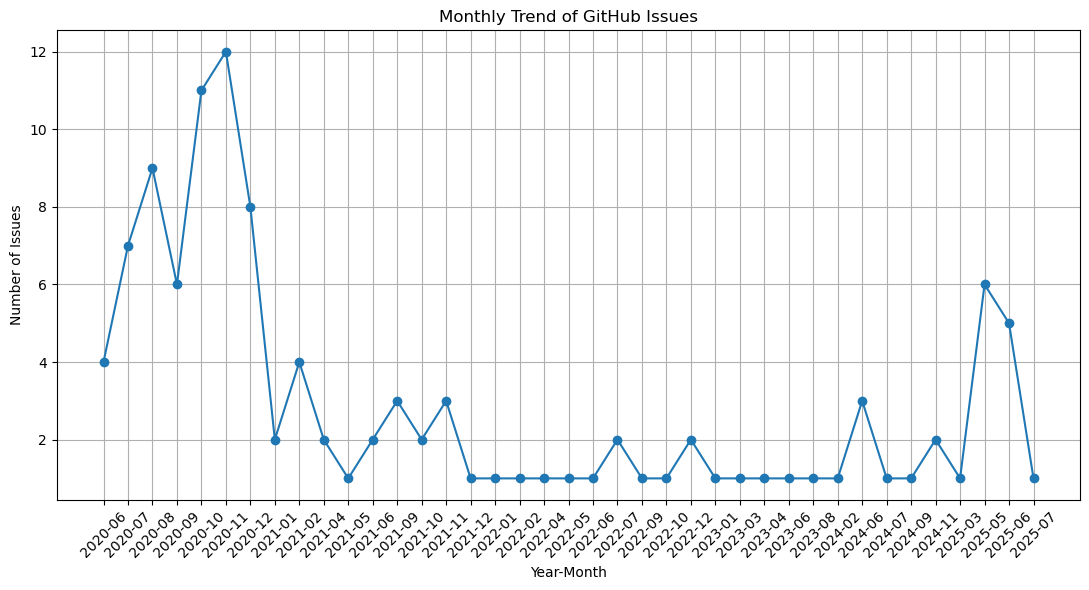

In [24]:
#Issues count trend — Line chart
plot_issue_monthly_trend(issue_df)

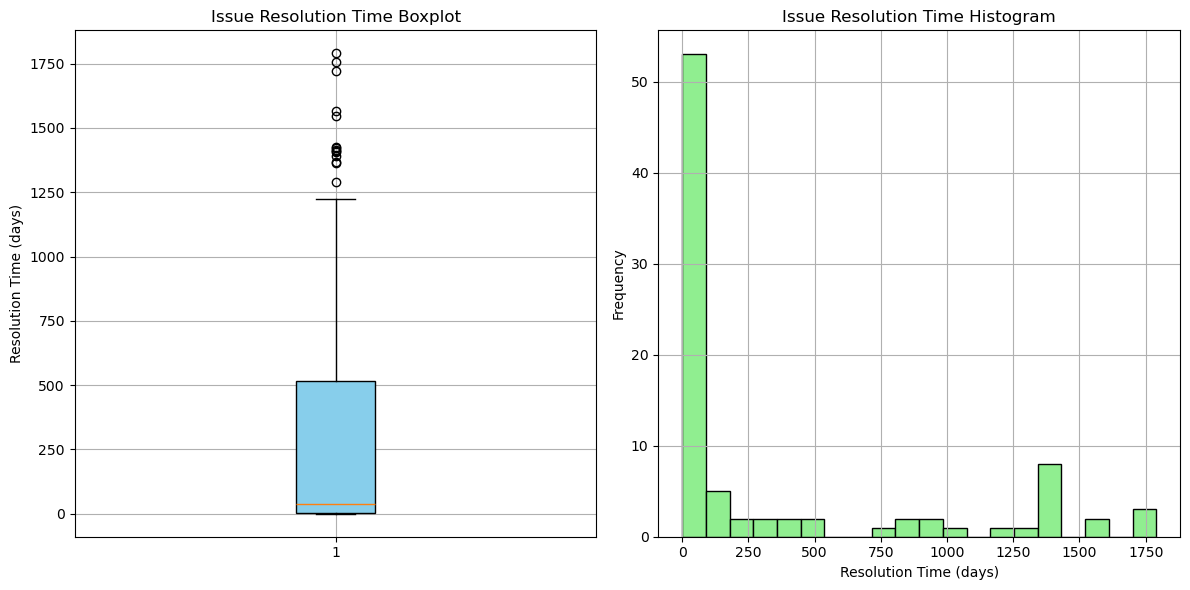

In [25]:
#Issues resolution time distribution — Histogram and boxplot
plot_issue_resolution_time_distribution(issue_df)

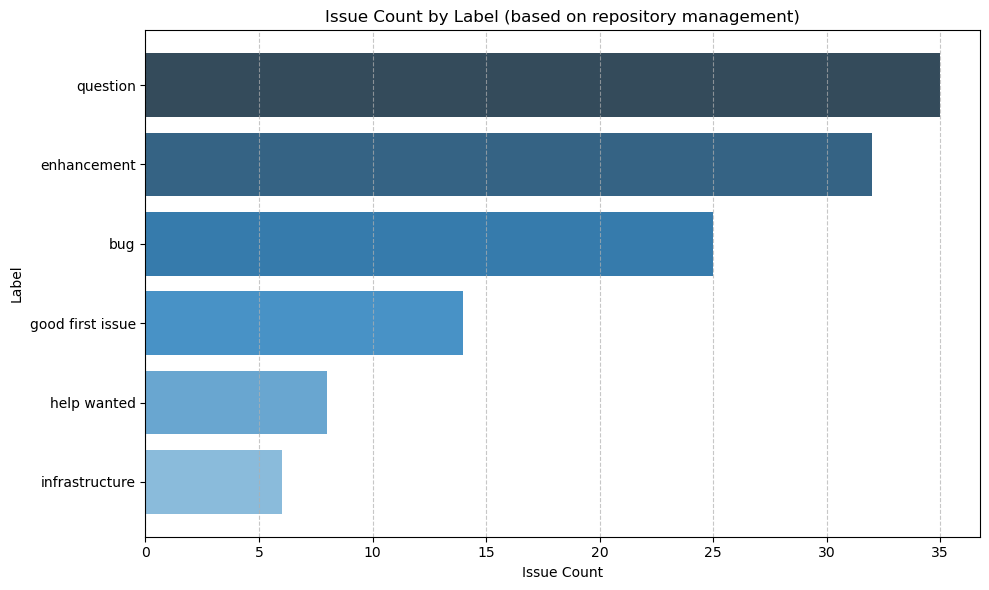

In [26]:
#Issues title distribution (based on repository management) — Bar chart
plot_issue_labels(issue_df, target_labels=None)

In [27]:
#Issues title distribution (based on programming language) — Text-based tree diagram
plot_lang_labels(issue_df)

There are 12 issues involving languages (open: 2, closed: 10).

lang
├── French (fr): total: 3, open: 0, closed: 3
├── Zulu (zu): total: 2, open: 2, closed: 0
├── Ukrainian (ua): total: 2, open: 0, closed: 2
├── Japanese (ja): total: 2, open: 0, closed: 2
├── German (de): total: 1, open: 0, closed: 1
├── Portuguese (pt): total: 1, open: 0, closed: 1
└── English (en): total: 1, open: 0, closed: 1
